In [ ]:
pip install -U pytorch-lightning segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 79.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import pytorch_lightning as pl
from torchvision.datasets import OxfordIIITPet

## Dane
Wykorzystamy zbiór [OxfordIIITPet](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html#oxfordiiitpet) do obu zadań, natomiast sposób ich wczytania będzie inny dla zadania segmentacji (wymaga zmiany **target_types** na "segmentation"). Do drugiej części wczytujemy obrazki jak do zadania klasyfikacji.
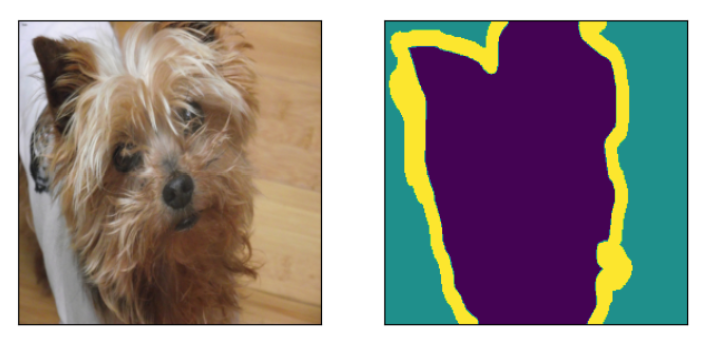



## Zadanie 0

Wczytaj zbiór OxfordIIIPet do zadania segmentacji, zbadaj co zawiera w środku oraz wyświetl przykładową maskę.

In [ ]:
# wczytaj zbiór z torchvision
# załaduj do DataLoadera (pamiętaj o podziale train, val, test)



In [ ]:
from pathlib import Path
from torchvision import datasets, transforms
import torch
import numpy as np

base_path = Path('/content')


transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


target_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).long())
])


trainset = datasets.OxfordIIITPet(
    root=base_path,
    split="trainval",
    download=True,
    transform=transform,
    target_transform=target_transform,
    target_types="segmentation"
)

testset = datasets.OxfordIIITPet(
    root=base_path,
    split="test",
    download=True,
    transform=transform,
    target_transform=target_transform,
    target_types="segmentation"
)

100%|██████████| 792M/792M [00:37<00:00, 21.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
customSEED=42

import torch
from torch.utils.data import DataLoader, random_split



np.random.seed(customSEED)
torch.manual_seed(customSEED)
torch.cuda.manual_seed_all(customSEED)

g = torch.Generator()
g.manual_seed(customSEED)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=g)


In [ ]:
print("Total length: " + f'{len(train_subset)+len(val_subset)+len(testset)}')

Total length: 7349


In [ ]:
image, mask = train_subset[16]

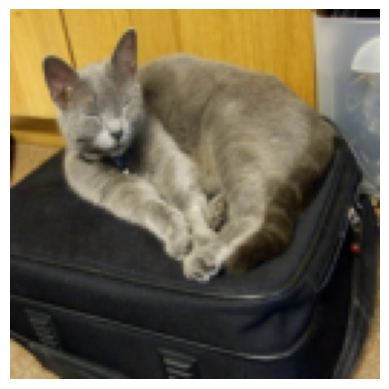

In [ ]:
plt.imshow(image.permute(1, 2, 0))
plt.axis('off')
plt.show()

KOTEK

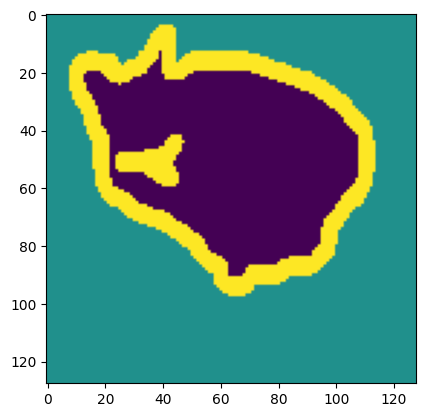

In [ ]:
mask_array = np.array(mask)
plt.imshow(mask_array)
plt.show()

## U-Net

Jest to popularna architektura która ma swój początek w zadaniu **segmentacji** biomedycznej. Do tej pory mieliśmy styczność z klasyfikacją, gdzie każdemu obrazkowi przypisywaliśmy kategorię, natomiast segmentacja polega na przypisaniu każdemu pikselowi kategorii.

Architektura składa się z enkodera i dekodera, pośredniej warstwy bottlenecka i połączeń typu skip (aka' pomost). Sieć enkodera jest klasyczną siecią konwolucyjną, w której zwiększa się liczba kanałów kosztem zmniejszenia rozdzielczości mapy. Sieć dekodera składa się z warstw *dekonwolucji*, które mają w przeciwieństwie do zwykłej konwolucji zwiększać rozdzielczość obrazka i zmniejszać liczbę kanałów. Dzięki temu końcowy wynik ma taki sam rozmiar jak wejściowy obrazek, co reprezentuje przypisanie klasy per piksel. Połączenia pomostowe służą do konkatenacji map z enkodera i dekodera, a celem jest zachowanie informacji na temat tego "co" i "gdzie" się znajduje. Dobre wytłumaczenie znajduje się [tutaj](https://www.kaggle.com/code/akshitsharma1/unet-architecture-explained-in-one-shot-tutorial).

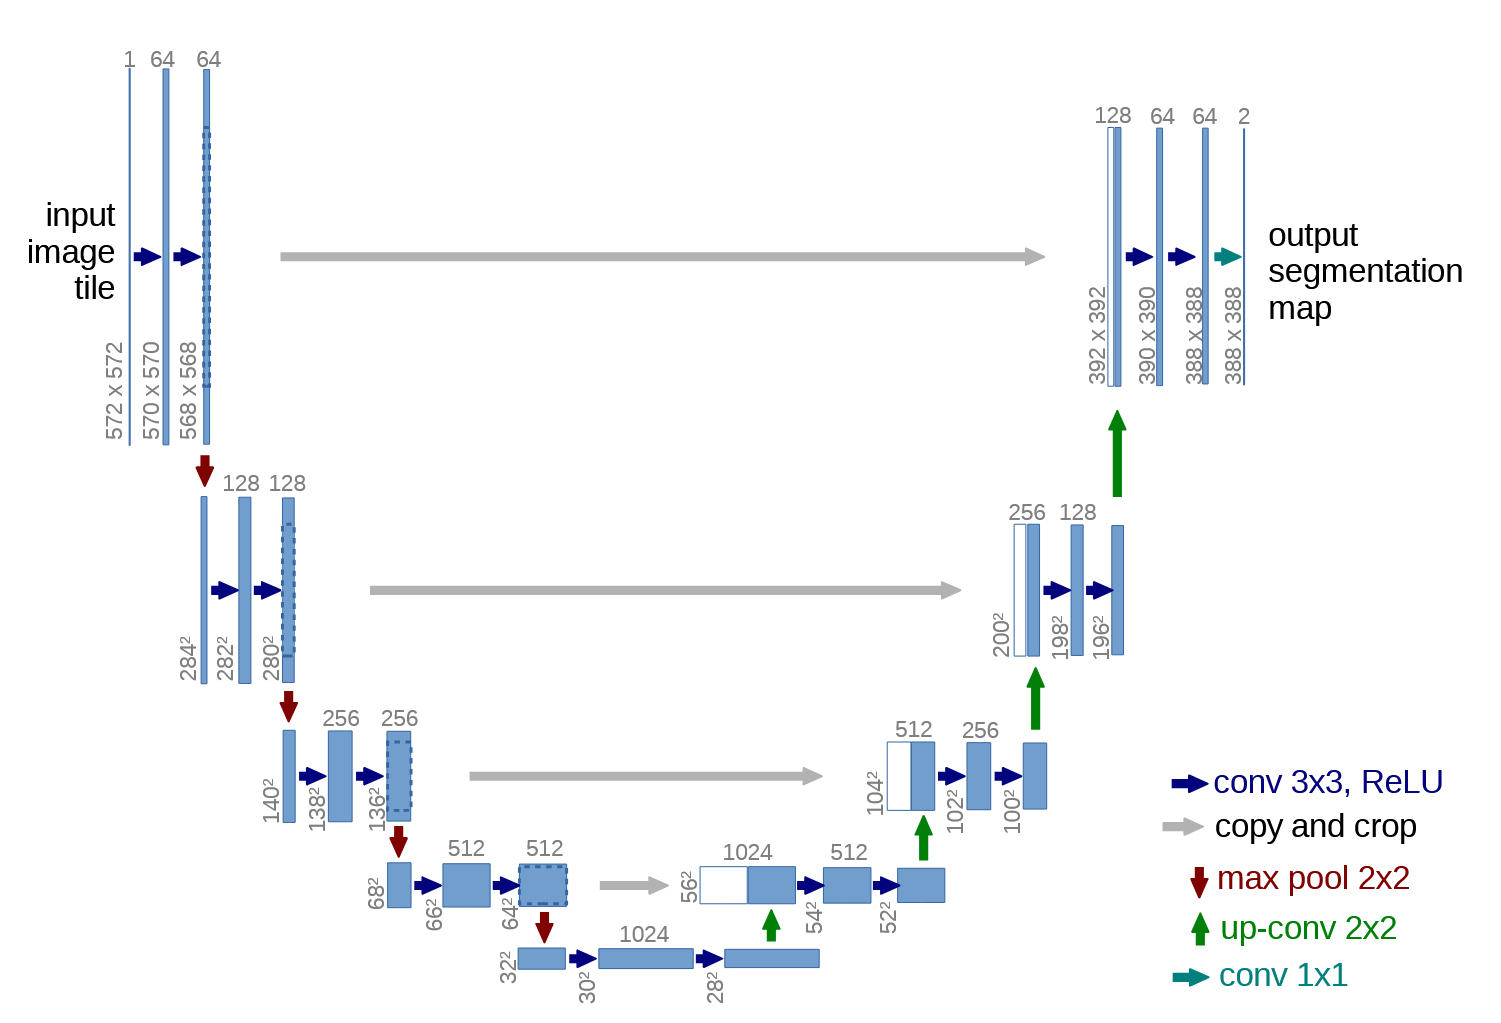

## Dekonwolucja

Dekonwolucja jest bratnią operacją konwolucji, ale jak już było wspomnianie, jej celem jest zwiększenie wymiarów przestrzennych. Składa się ona z kroków
- Upsampling: zwiększenie rozmiaru mapy zwykle dodając "puste" wiersze i kolumny
- Convolution: warstwa konwolucyjna (logiczne - czegoś też chcemy się nauczyć)
- Stride: $> 1$ zwiększa wymiar przestrzenny mapy
- Padding: to samo co w zwykłej konwolucji
- Activation: funkcja aktywacji (nieliniowa!, zwykle ReLU)

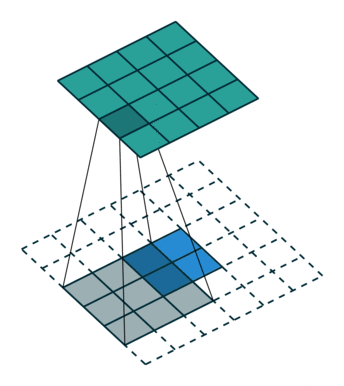

## Zadanie 1.1
Zaimplementuj blok warstwy enkodera, który będzie wykonywał m.in. operację konwolucji (zmniejszanie wymiary przestrzennego) oraz max-pooling. Jedną pułapką jest tutaj fakt, że enkoder musi zwracać dwie rzeczy - $x_{skip}$ jako wejście do dekodera, oraz $x_{down}$ po warstwie poolingu do dalszej warstwy enkodera.

$x_{skip} = ConvBlock(x)$

$x_{down} = MaxPool(x_{skip})$

gdzie $ConvBlock$ stanowi pipeline *konwolucja, batch-normalization, aktywacja* powtórzone $M$ razy (może być raz). Jest on już zaimplementowany niżej jako ```DoubleConv``` - możesz go dostosować do swoich potrzeb lub zostawić jak jest.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None):
        super().__init__()

        if not hidden_channels:
            hidden_channels = out_channels

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class DownBlock(nn.Module): # blok budulcowy enkodera

  def __init__(self, input, output): # dodaj parametry
    super().__init__()
    self.conv1=DoubleConv(input,output)
    self.pool=nn.MaxPool2d((2,2))

    pass

  def forward(self, x): # dodaj parametry
    x_skip=self.conv1(x)
    x_down=self.pool(x_skip)

    ...
    return x_skip, x_down

## Zadanie 1.2
Zaimplementuj *blok* warstwy dekodera, która będzie wykonywała operację dekonwolucji oraz konkatenacji cech z enkodera. Przetwarzanie powinno być według schematu:

*$x_{up} = ConvTranspose(x)$

$x_{cat} = Concat(x_{up}, s)$

$y = ConvBlock(x_{out})$

Nowa warstwa dekonwolucji jest zaimplementowana w torchu [ConvTranspose2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). Należy zwrócić uwagę na **zgodność kształtów** oraz **liczbę kanałów** (szczególnie po konkatenacji!).

*alternatywnie można użyć warswty [Upsamplingu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html) + konwolucji

In [ ]:
class UpBlock(nn.Module): # blok budulcowy dekodera

  def __init__(self, input, output): # dodaj parametry
    super().__init__()
    self.transpose=nn.ConvTranspose2d(input,output,kernel_size=2,stride=2)
    self.conv1=DoubleConv(output*2,output)

  def forward(self, x, s): # dodaj parametry
    x_up=self.transpose(x)
    x_cat = torch.cat([x_up, s], dim=1)
    y=self.conv1(x_cat)
    return y

Zalecam zrobienie krótkiego sanity-check aby sprawdzić, czy dwa bloki łączą się poprawnie

In [ ]:
x = torch.randn(1, 3, 128, 128)
down_block = DownBlock(3, 32) # dodaj argumenty
up_block = UpBlock(32,32) # dodaj argumenty

x_skip, x_down = down_block(x)
x_up = up_block(x_down, x_skip)

print(x_skip.shape, x_down.shape, x_up.shape)

torch.Size([1, 32, 128, 128]) torch.Size([1, 32, 64, 64]) torch.Size([1, 32, 128, 128])


## Zadanie 2.1
Następnym zadaniem jest wykorzystanie bloków do implementacji pełnej sieci. Niech nasza sieć składa się z N bloków enkodera $(E1​...En​)$, jednego bottlenecku $(B)$ i N bloków dekodera $(Dn​...D1​)$. Schemat będzie miał postać:

#### Enkoder
1. $(x1​,s1​)=E1​(input)$
2. $(x2​,s2​)=E2​(x1​)$
3. $(x3​,s3​)=E3​(x2​)$
4. $(x4​,s4​)=E4​(x3​)$

#### Bottleneck
5. $b=B(x4​)$ (zwykły blok konwolucyjny)

#### Dekoder
6. $d4​=D4​(b,s4​)$
7. $d3​=D3​(d4​,s3​)$
8. $d2​=D2​(d3​,s2​)$
9. $d1​=D1​(d2​,s1​)$

#### Spłaszczenie wyjścia
10. $output=Conv_{1x1}(d1​)$ --> wykorzystuje konwolucję $1x1$ do pozbycia się wymiaru kanału. Otrzymujemy tutaj $H \times W \times K$ predykcji (bo dla każdego piksela) i każdej klasy.

Wskazówki
- Rozmiar wejściowy: Musi być podzielny przez $2^{liczba poziomów}$ (dlaczego?), najlepiej używać potęg dwójki typu 256, 512
- Padding: równy 1
- Liczba kanałów: w enkoderze podwajamy $64 → 128 → 256$, w dekoderze dzielimy przez dwa $256 → 128 → 64$
- Konkatenacja: po wymiarze kanałów
- Wyjście: musi być takiego samo wymiary przestrzennego jak wejście, a liczba kanałów będzie odpowiadać liczbie klas.

In [ ]:
class UNet(nn.Module):
  def __init__(self, input, output):
    super().__init__()
    self.down_blocks = nn.ModuleList()
    self.up_blocks = nn.ModuleList()
    self.bottleneck = DoubleConv(input, output)


    features = [64, 128, 256, 512]

    curr_in = input
    for f in features:
        self.down_blocks.append(DownBlock(curr_in, f))
        curr_in = f
    self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

    for f in reversed(features):
        self.up_blocks.append(UpBlock(f * 2, f))


    self.conv = nn.Conv2d(features[0], output, kernel_size=1)

  def forward(self, input):
    skip_history = []

    x_down = input
    for i in range(len(self.down_blocks)):
      x_skip, x_down = self.down_blocks[i](x_down)
      skip_history.append(x_skip)

    b = self.bottleneck(x_down)

    skip_history = skip_history[::-1]
    d = b
    for i in range(len(self.up_blocks)):
      d = self.up_blocks[i](d, skip_history[i])

    return self.conv(d)

## Zadanie 2.2
Kolejnym krokiem jest wyuczenie sieci do zadania segmentacji. Wykorzystaj ```nn.CrossEntropyLoss``` jako funkcję straty (lub posłuż się bardziej dostosowanymi metrykami jak [Dice Loss](https://smp.readthedocs.io/en/latest/losses.html#diceloss) jeśli uczenie będzie szło bardzo źle). W tym celu konieczne będzie spłaszczenie wyniku $B \times W \times H \times K$ do $B \times (WH) \times K$. Wyświetl krzywą uczenia oraz dokładność dla każdej klasy. Dodatkowo zbieraj co $M$ epok przykładowe predykcje (dla zbioru walidacyjnego) i wyświetl jak w trakcie trenowania zmieniała się maska segmentacji (najlepiej zostaw dataloder dla zbioru val z ```shuffle=False```)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

class TrainerTorch:
    def __init__(self,
                 model,
                 n_epochs=20,
                 batch_size=16,
                 lr=0.01,
                 patience=3,
                 optimizer: str = "SGD",
                 use_early_stopping: bool = False,
                 generator=None,
                 regularization: bool = False,
                 lambda_reg=0.01,
                 cosine_learning_rate: bool = False):

        self.model = model
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.optimizer_name = optimizer
        self.use_early_stopping = use_early_stopping
        self.generator = generator
        self.regularization = regularization
        self.cosine_learning_rate = cosine_learning_rate
        self.lambda_reg = lambda_reg

        self.lr_history = defaultdict(list)
        self.history = defaultdict(list)
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()

    def train(self, train_dataset, val_dataset):
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            generator=self.generator,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        print(f"Rozpoczynam trening na: {self.device}")

        weight_decay = self.lambda_reg if self.regularization else 0.0

        if self.optimizer_name == "SGD":
            optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)

        if self.cosine_learning_rate:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_epochs)

        for epoch in range(self.n_epochs):
            self.model.train()
            epoch_loss = 0.0
            epoch_correct = 0
            total_pixels = 0

            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)
                y = y.squeeze(1).long() - 1

                optimizer.zero_grad()
                output = self.model(X)
                loss = self.criterion(output, y)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * X.size(0)
                predicted = output.argmax(dim=1)
                epoch_correct += (predicted == y).sum().item()
                total_pixels += y.numel()

            if self.cosine_learning_rate:
                scheduler.step()
                self.lr_history['lr'].append(optimizer.param_groups[0]['lr'])

            train_l = epoch_loss / len(train_loader.dataset)
            train_acc = epoch_correct / total_pixels

            self.model.eval()
            with torch.no_grad():
                val_l, val_acc, _ = self.evaluate(val_loader)

                self.history['train_loss'].append(train_l)
                self.history['val_loss'].append(val_l)
                self.history['train_acc'].append(train_acc)
                self.history['val_acc'].append(val_acc)

                print(f"Epoch {epoch+1}/{self.n_epochs} | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_acc:.4f}")

                if val_l < self.best_val_loss:
                    self.best_val_loss = val_l
                    self.early_stop_counter = 0
                    torch.save({
                        'model_state_dict': self.model.state_dict(),
                    }, 'checkpoint.pt')
                else:
                    self.early_stop_counter += 1

                if self.use_early_stopping and self.early_stop_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        self.plot_history()
        checkpoint = torch.load('checkpoint.pt', weights_only=True)
        self.model.load_state_dict(checkpoint['model_state_dict'])

    def evaluate(self, loader):
        losses, accs = [], []

        for X, y in loader:
            X, y = X.to(self.device), y.to(self.device)
            y = y.squeeze(1).long() - 1

            A = self.model(X)
            loss = self.criterion(A, y)
            losses.append(loss.item())

            predicted_classes = A.argmax(dim=1)
            acc = (predicted_classes == y).float().mean().item()
            accs.append(acc)

        return np.mean(losses), np.mean(accs), None

    def predict(self, x_test):
        test_loader = DataLoader(x_test, batch_size=self.batch_size, shuffle=False)
        self.model.eval()
        with torch.no_grad():
          loss, acc, _ = self.evaluate(test_loader)
          print(f"Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")
          return None

    def plot_history(self):
      epochs = range(1, len(self.history['train_loss']) + 1)
      plt.figure(figsize=(16, 5))
      plt.subplot(1, 2, 1)
      plt.plot(epochs, self.history['train_loss'], label='Train Loss')
      plt.plot(epochs, self.history['val_loss'], label='Val Loss')
      plt.title('Loss')
      plt.legend()
      plt.subplot(1, 2, 2)
      plt.plot(epochs, self.history['train_acc'], label='Train Acc')
      plt.plot(epochs, self.history['val_acc'], label='Val Acc')
      plt.title('Pixel Accuracy')
      plt.legend()
      plt.show()

Rozpoczynam trening na: cuda
Epoch 1/15 | Train Loss: 0.6480 | Val Loss: 0.5800 | Val Acc: 0.7716
Epoch 2/15 | Train Loss: 0.5361 | Val Loss: 0.5654 | Val Acc: 0.7680
Epoch 3/15 | Train Loss: 0.4971 | Val Loss: 0.4877 | Val Acc: 0.8142
Epoch 4/15 | Train Loss: 0.4503 | Val Loss: 0.5634 | Val Acc: 0.7779
Epoch 5/15 | Train Loss: 0.4144 | Val Loss: 0.5119 | Val Acc: 0.8107
Epoch 6/15 | Train Loss: 0.3903 | Val Loss: 0.3931 | Val Acc: 0.8481
Epoch 7/15 | Train Loss: 0.3594 | Val Loss: 0.3759 | Val Acc: 0.8556
Epoch 8/15 | Train Loss: 0.3432 | Val Loss: 0.4648 | Val Acc: 0.8234
Epoch 9/15 | Train Loss: 0.3239 | Val Loss: 0.3295 | Val Acc: 0.8749
Epoch 10/15 | Train Loss: 0.3106 | Val Loss: 0.3139 | Val Acc: 0.8801
Epoch 11/15 | Train Loss: 0.2860 | Val Loss: 0.3074 | Val Acc: 0.8829
Epoch 12/15 | Train Loss: 0.2665 | Val Loss: 0.2851 | Val Acc: 0.8912
Epoch 13/15 | Train Loss: 0.2462 | Val Loss: 0.2699 | Val Acc: 0.8957
Epoch 14/15 | Train Loss: 0.2326 | Val Loss: 0.2636 | Val Acc: 0.8981


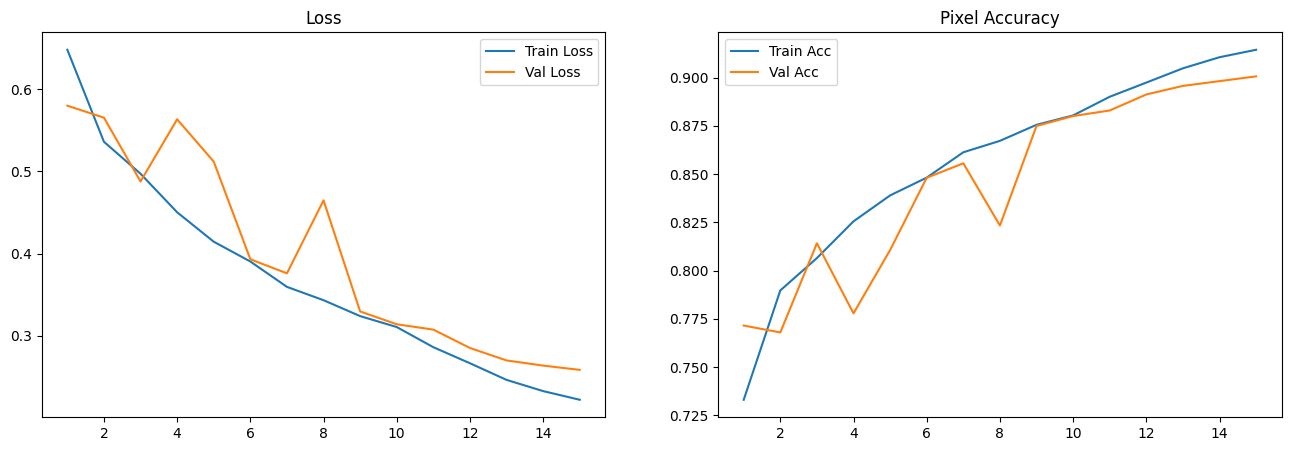

Test Loss: 0.2754, Test Acc: 0.8963


In [ ]:
UNET = UNet(3,3)
trainer = TrainerTorch(model=UNET, n_epochs=15, lr=0.001, optimizer="Adam", cosine_learning_rate=True, regularization=True, lambda_reg=1e-4)
trainer.train(train_subset, val_subset)
trainer.predict(testset)



Ciekawe wykresy, niestabilne uczenie, może trzeba ogarnąć LR, możliwy overfitting, lecz accuracy na poziomie 90%

## Autoenkoder

Autoenkoder to architektura zaliczana do uczenia nienadzorowanego (unsupervised learning), co oznacza, że trenujemy ją wyłącznie na danych wejściowych, bez udziału etykiet. Model ten składa się z połączonego enkodera i dekodera, a jego celem jest minimalizacja błędu rekonstrukcji wejścia (np. Mean Squared Error).

Matematycznie problem ten sprowadza się do znalezienia takiego zbioru parametrów θ, który minimalizuje funkcję straty: $$ L(x^{(t)}, g_{\theta}(f_{\theta}(x^{(t)}))) $$ dla *enkodera* $f$ i *dekodera* $g$. Kluczową cechą jest to, że wymiar na wyjściu enkodera jest zazwyczaj mniejszy niż danych wejściowych. Ma to na celu wymuszenie kompresji danych do tzw. przestrzeni ukrytej (latent space), co zapobiega nauczeniu się przez sieć trywialnej funkcji tożsamościowej. Dekoder zajmuje się następnie rekonstrukcją oryginalnego obrazu na podstawie tej skompresowanej reprezentacji.

Bardzo dobrą praktyką jest celowe zaszumianie danych wejściowych na etapie treningu. Działa to jak silna regularyzacja – enkoder musi wtedy nauczyć się ekstrahować najważniejsze, kluczowe cechy danych, aby być w stanie odtworzyć czysty sygnał. Tak wytrenowany autoenkoder znajduje zastosowanie głównie w tworzeniu zwartych osadzeń danych (embeddingów), które mogą zostać wykorzystane w dalszych etapach, np. w zadaniu klasyfikacji.

### Przepływ danych

1. Enkoder: zajmuje się kompresją wejściowego obrazu, zwykle do zmniejszania rozmiaru przestrzennego używamy $stride=2$ zamiast max-pooling.
2. Bottleneck: punkt największej kompresji, wykorzystuje znany już $AdaptiveAvgPool2d$ aby wymusić mały rozmiar przestrzenny (np. $2 \times 2$) do dekodowania
3. Dekoder: odbudowuje obraz z wykorzystaniem wcześniej omawianych transponowanych konwolucji.

### Funkcja straty
Wykorzystamy funkcję straty [MSE](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#mseloss) do porównania obrazu wejściowego i zrekonstruowanego. Alternatywnie może być wykorzystane [MAE](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) ponieważ jest mniej odporne na wartości odstające. Wartości obrazu powinny być znormalizowane, ale wyjścia sieci nie muszą być ograniczone.

## Zadanie 3.1

Zaimplementuj sieć autoenkoder. Będzie ona podobna do sieci U-Net, natomiast nie używa *skip connections* do połączenia dwóch części (ma prostszy schemat). Wyucz sieć traktując obraz wejściowy jako "labele" (pamiętamy, że jest to zadanie nienadzorowane, ale nadal potrzebujemy jakiegoś ground-truth). Wyświetl ciekawsze przykłady rekonstrukcji i zawrzyj wnioski na temat łatwości uczenia sieci i jakości zrekonstruowanych obrazów.

**Uwaga**: możecie wczytać zbiór danych do nauki na wszytkich $37$ klasach, lub tylko na klasach binarnych - dla **target_types=binary-category**. Nie ma to oczywiście znaczenia do nauki autoenkodera, ale w zadaniu 3.2 potrzebne są kategorie - być może lepiej będzie zwizualizować tylko jak przestrzeń się układa dla psów i kotów, niż dla każdej z 37 klas.

In [ ]:
from pathlib import Path
from torchvision import datasets, transforms


base_path = Path('/content')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),

])


trainset = datasets.OxfordIIITPet(
    root=base_path,
    split="trainval",
    download=True,
    transform=transform,
    target_types="binary-category"
)

testset = datasets.OxfordIIITPet(
    root=base_path,
    split="test",
    download=True,
    transform=transform,
    target_types="binary-category"
)

In [ ]:
customSEED=42

import torch
from torch.utils.data import DataLoader, random_split



np.random.seed(customSEED)
torch.manual_seed(customSEED)
torch.cuda.manual_seed_all(customSEED)

g = torch.Generator()
g.manual_seed(customSEED)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=g)


In [ ]:
class Encoder(nn.Module): # oddzielne sieci dla przejrzystości i łatwości dalszego użycia
    def __init__(self, in_channels, features):
        super().__init__()
        self.blocks = nn.ModuleList()
        for f in features:
            self.blocks.append(nn.Sequential(
                DoubleConv(in_channels, f),
                nn.Conv2d(f, f, kernel_size=3, stride=2, padding=1)
            ))
            in_channels = f

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


In [ ]:
class Decoder(nn.Module):
    def __init__(self, features, out_channels):
        super().__init__()
        self.blocks = nn.ModuleList()
        reversed_features = features[::-1]

        for i in range(len(reversed_features) - 1):
            self.blocks.append(nn.Sequential(
                nn.ConvTranspose2d(reversed_features[i], reversed_features[i+1], kernel_size=2, stride=2),
                DoubleConv(reversed_features[i+1], reversed_features[i+1])
            ))


        self.final_upsampling = nn.Sequential(
            nn.ConvTranspose2d(reversed_features[-1], 64, kernel_size=2, stride=2),
            DoubleConv(64, 64),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            DoubleConv(32, 32),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            DoubleConv(16, 16),
            nn.ConvTranspose2d(16, 16, kernel_size=2, stride=2),
        )
        self.final_conv = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.final_upsampling(x)
        return self.final_conv(x)

In [ ]:
class CNNAutoencoder(nn.Module): # łączymy tutaj logikę enkodera i dekodera
    def __init__(self, in_channels=3, bottleneck=4):
        super().__init__()
        features = [64, 128, bottleneck]

        self.encoder = Encoder(in_channels, features)
        self.decoder = Decoder(features, in_channels)
        self.bottleneck = nn.AdaptiveAvgPool2d((2,2))

    def embeddings(self, x): # użyj tylko enkodera i zwróc spłaszczony wynik
      x=self.encoder(x)
      x=self.bottleneck(x)
      return torch.flatten(x, start_dim=1)

    def forward(self, x):
        x = self.encoder(x)
        x=self.bottleneck(x)
        x = self.decoder(x)
        return x


### Zadanie 3.2
Wyucz sieć autoeknkodera. Klasycznie loguj funkcję straty (czy będziesz logować accuracy??), oraz zbieraj rekonstrukcje dla zbioru walidacyjnego w trakcie uczenia i wyświetl jak się zmieniały w trakcie trenowania. Eksperymenty wykonaj dla różnej wielkości *bottlenecka* (np. $4, 16, 32$) i zapisz swoje obserwacje.

Nie liczymy accuracy, bo mamy marne szanse trafić idealnie w ten są samą wartość pixela

In [ ]:
class TrainerTorch:
    def __init__(self,
                 model,
                 n_epochs=20,
                 batch_size=16,
                 lr=0.001,
                 patience=3,
                 optimizer: str = "Adam",
                 use_early_stopping: bool = False,
                 generator=None,
                 regularization: bool = False,
                 lambda_reg=0.01):

        self.model = model
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.optimizer_name = optimizer
        self.use_early_stopping = use_early_stopping
        self.generator = generator
        self.regularization = regularization
        self.lambda_reg = lambda_reg

        self.history = defaultdict(list)
        self.reconstructions = []
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.criterion = nn.MSELoss()

    def train(self, train_dataset, val_dataset):
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        print(f"Autoencoder Training na: {self.device}")

        optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr) if self.optimizer_name == "Adam" \
                    else torch.optim.SGD(self.model.parameters(), lr=self.lr)

        for epoch in range(self.n_epochs):
            self.model.train()
            epoch_loss = 0.0

            for X, _ in train_loader:
                X = X.to(self.device)

                optimizer.zero_grad()
                output = self.model(X)


                loss = self.criterion(output, X)

                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * X.size(0)

            train_l = epoch_loss / len(train_loader.dataset)

            self.model.eval()
            with torch.no_grad():
                val_l, sample_rec = self.evaluate(val_loader)

                self.history['train_loss'].append(train_l)
                self.history['val_loss'].append(val_l)


                self.reconstructions.append(sample_rec)

                print(f"Epoch {epoch+1}/{self.n_epochs} | Train Loss: {train_l:.6f} | Val Loss: {val_l:.6f}")

                if val_l < self.best_val_loss:
                    self.best_val_loss = val_l
                    self.early_stop_counter = 0
                    torch.save({'model_state_dict': self.model.state_dict()}, 'best_ae.pt')
                else:
                    self.early_stop_counter += 1

                if self.use_early_stopping and self.early_stop_counter >= self.patience:
                    break

    def evaluate(self, loader):
        losses = []

        sample_to_save = None

        for X, _ in loader:
            X = X.to(self.device)
            output = self.model(X)
            loss = self.criterion(output, X)
            losses.append(loss.item())

            if sample_to_save is None:

                sample_to_save = output[0].cpu().permute(1, 2, 0).numpy()

        return np.mean(losses), sample_to_save

    def plot_reconstruction_progress(self):

        n = len(self.reconstructions)
        cols = 5
        rows = (n // cols) + 1
        plt.figure(figsize=(15, 3 * rows))
        for i, img in enumerate(self.reconstructions):
            plt.subplot(rows, cols, i+1)
            plt.imshow(np.clip(img, 0, 1))
            plt.title(f"Epoch {i+1}")
            plt.axis('off')
        plt.show()

In [ ]:
auto_4=CNNAutoencoder(bottleneck=4)
auto_8=CNNAutoencoder(bottleneck=8)
auto_16=CNNAutoencoder(bottleneck=16)
auto_32=CNNAutoencoder(bottleneck=32)

In [ ]:
trainer = TrainerTorch(model=auto_4, n_epochs=10, lr=0.001, optimizer="Adam", regularization=True, lambda_reg=1e-4)
trainer.train(train_subset, val_subset)

Autoencoder Training na: cuda
Epoch 1/10 | Train Loss: 0.059778 | Val Loss: 0.039240
Epoch 2/10 | Train Loss: 0.034837 | Val Loss: 0.032171
Epoch 3/10 | Train Loss: 0.032107 | Val Loss: 0.030900
Epoch 4/10 | Train Loss: 0.031506 | Val Loss: 0.030301
Epoch 5/10 | Train Loss: 0.030645 | Val Loss: 0.031327
Epoch 6/10 | Train Loss: 0.030259 | Val Loss: 0.031406
Epoch 7/10 | Train Loss: 0.030104 | Val Loss: 0.030698
Epoch 8/10 | Train Loss: 0.029704 | Val Loss: 0.028745
Epoch 9/10 | Train Loss: 0.029255 | Val Loss: 0.030498
Epoch 10/10 | Train Loss: 0.029338 | Val Loss: 0.029506


AttributeError: 'TrainerTorch' object has no attribute 'predict'

Z automatu wkleiłem wywołanie funkcji predict, której tutaj nie ma. Żeby nie marnować zasobów i czasu to to niestety tutaj zostanie

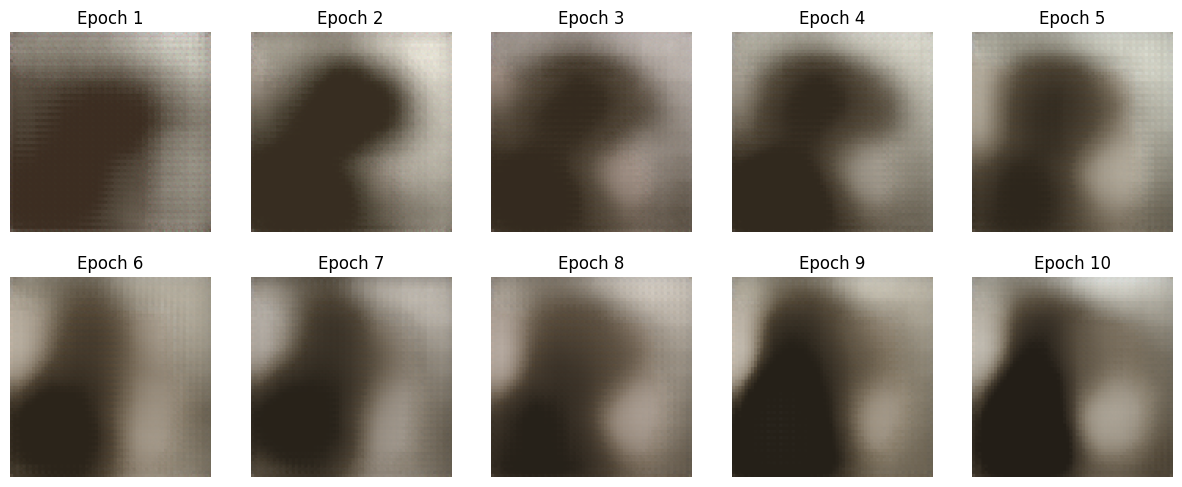

In [ ]:
trainer.plot_reconstruction_progress()

In [ ]:
trainer = TrainerTorch(model=auto_8, n_epochs=10, lr=0.001, optimizer="Adam", regularization=True, lambda_reg=1e-4)
trainer.train(train_subset, val_subset)


Autoencoder Training na: cuda
Epoch 1/10 | Train Loss: 0.054289 | Val Loss: 0.032473
Epoch 2/10 | Train Loss: 0.032195 | Val Loss: 0.030700
Epoch 3/10 | Train Loss: 0.030753 | Val Loss: 0.030058
Epoch 4/10 | Train Loss: 0.029471 | Val Loss: 0.033120
Epoch 5/10 | Train Loss: 0.028708 | Val Loss: 0.029583
Epoch 6/10 | Train Loss: 0.027867 | Val Loss: 0.028340
Epoch 7/10 | Train Loss: 0.027078 | Val Loss: 0.028103
Epoch 8/10 | Train Loss: 0.026441 | Val Loss: 0.033739
Epoch 9/10 | Train Loss: 0.026191 | Val Loss: 0.026345
Epoch 10/10 | Train Loss: 0.025712 | Val Loss: 0.029533


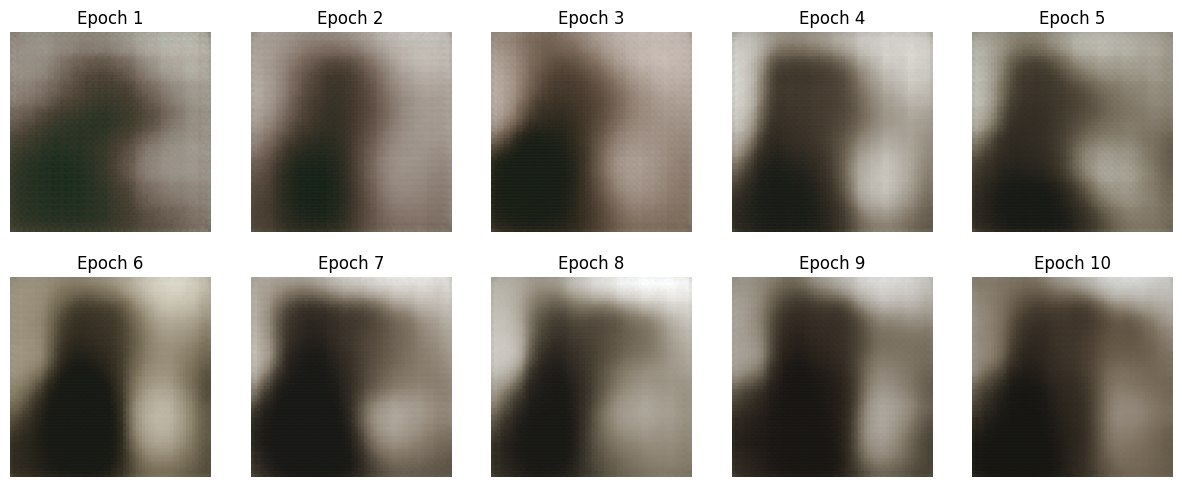

In [ ]:
trainer.plot_reconstruction_progress()

In [ ]:
trainer = TrainerTorch(model=auto_16, n_epochs=10, lr=0.001, optimizer="Adam", regularization=True, lambda_reg=1e-4)
trainer.train(train_subset, val_subset)


Autoencoder Training na: cuda
Epoch 1/10 | Train Loss: 0.063311 | Val Loss: 0.035685
Epoch 2/10 | Train Loss: 0.032169 | Val Loss: 0.031192
Epoch 3/10 | Train Loss: 0.030659 | Val Loss: 0.030701
Epoch 4/10 | Train Loss: 0.029908 | Val Loss: 0.027980
Epoch 5/10 | Train Loss: 0.028534 | Val Loss: 0.028680
Epoch 6/10 | Train Loss: 0.027507 | Val Loss: 0.027560
Epoch 7/10 | Train Loss: 0.027008 | Val Loss: 0.025616
Epoch 8/10 | Train Loss: 0.026275 | Val Loss: 0.025468
Epoch 9/10 | Train Loss: 0.025320 | Val Loss: 0.025550
Epoch 10/10 | Train Loss: 0.024691 | Val Loss: 0.024062


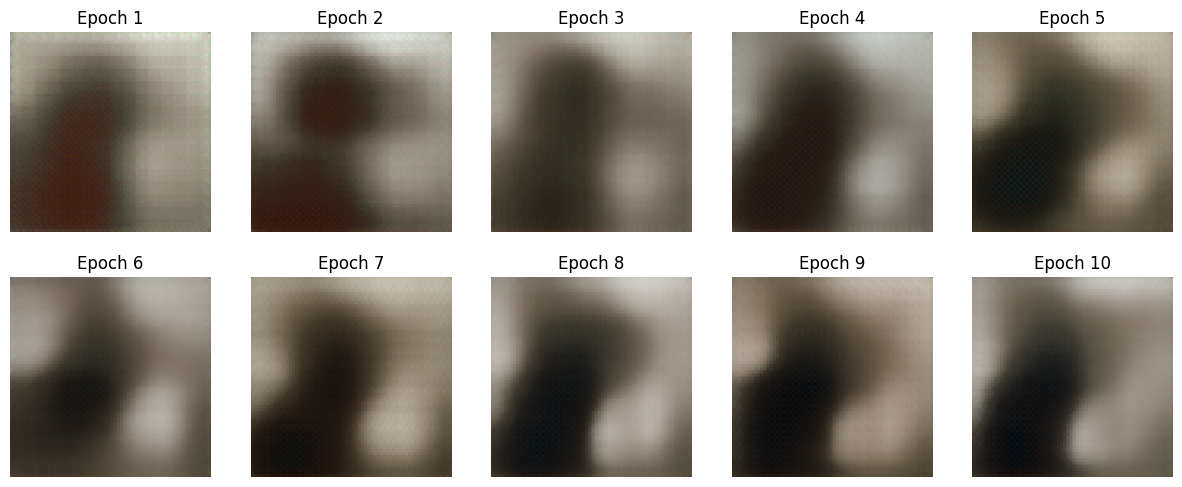

In [ ]:
trainer.plot_reconstruction_progress()

In [ ]:
trainer = TrainerTorch(model=auto_32, n_epochs=10, lr=0.001, optimizer="Adam",regularization=True, lambda_reg=1e-4)
trainer.train(train_subset, val_subset)


Autoencoder Training na: cuda
Epoch 1/10 | Train Loss: 0.075085 | Val Loss: 0.039613
Epoch 2/10 | Train Loss: 0.032507 | Val Loss: 0.031277
Epoch 3/10 | Train Loss: 0.030992 | Val Loss: 0.029993
Epoch 4/10 | Train Loss: 0.030239 | Val Loss: 0.032218
Epoch 5/10 | Train Loss: 0.029635 | Val Loss: 0.028955
Epoch 6/10 | Train Loss: 0.029568 | Val Loss: 0.029690
Epoch 7/10 | Train Loss: 0.028666 | Val Loss: 0.028483
Epoch 8/10 | Train Loss: 0.027223 | Val Loss: 0.026755
Epoch 9/10 | Train Loss: 0.026617 | Val Loss: 0.025247
Epoch 10/10 | Train Loss: 0.025937 | Val Loss: 0.024903


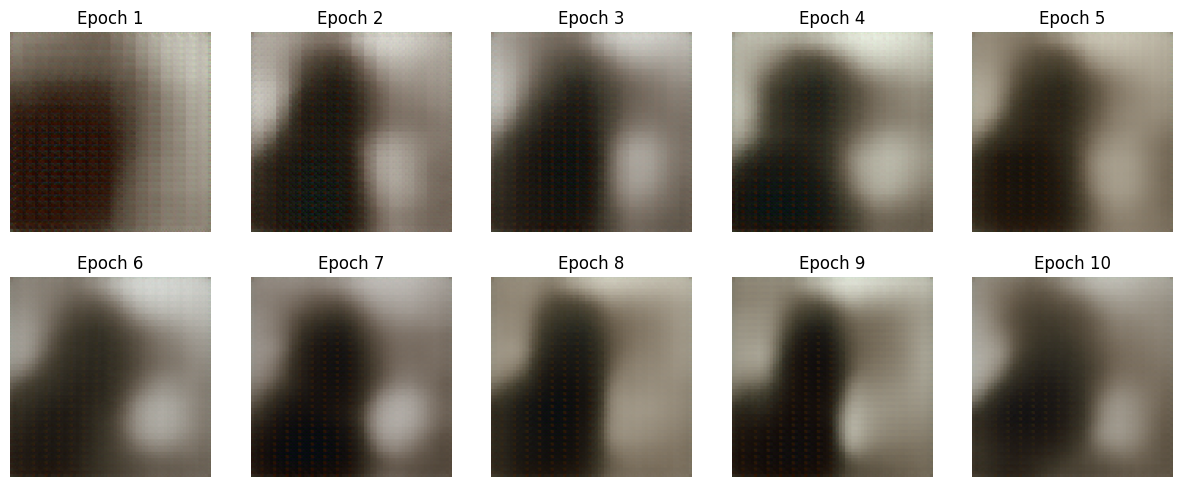

In [ ]:
trainer.plot_reconstruction_progress()

Jak widać tym więcej bottleneck tym ostrzejszy i lepszej jakości obraz już na samym początku. Nadal na nim widać kropki RGB,

## *Zadanie 3.3
Zwizualizuj wektor osadzeń przy pomocy *T-SNE*. Do tego celu potrzeba będzie spłaszczyć mapę powstałą w wyniku przejścia przez enkoder. Nie jest tutaj potrzebna sieć dekodera. Zwróć uwagę na to, czy klasy są wizualnie dobrze rozdzielone.